# Proyecto - Análisis de Datos
---

- Jose Wong

Este notebook contiene el script utilizado para la fase de análisis del proyecto.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Analisis Computacional de Datos/proyecto/dataset_analista_final_procesado.csv')
df.head()

,id_oferta,cargo,empresa,ciudad,salario_publicado,salario_mensual_base,segmento_salarial,experiencia_requerida,nivel_experiencia,educacion_minima,educacion_minima_valor,modalidad,es_remoto,es_presencial,tipo_contrato,jornada,tiempo_parcial,menciones_tecnologia
0,8C39916808949D3F61373E686DCF3405,Analista de Créditos y Cobranzas,Eurofirms Perú,San Isidro,0,NaN,NaN,0,Junior,universitario,4,Presencial,0,1,Contrato por Inicio o Incremento de Actividad,Completa,0,4
1,ED31FA4ABCE1FFAE61373E686DCF3405,Analista de Marketing,Grupo DN,Villa El Salvador,0,NaN,NaN,3,Mid-Level,universitario,4,Presencial,0,1,Contrato por Necesidades del Mercado,Completa,0,5
2,CDCE5090A62C406161373E686DCF3405,Analista de Comercial / Ventas,Importante empresa del sector,Lima,0,NaN,NaN,0,Junior,universitario,4,Remoto,1,0,Contrato por Inicio o Incremento de Actividad,Completa,0,3
3,CA0D5356E06046B061373E686DCF3405,Analista (General),OPTICAL NETWORKS S.A.C.,Surquillo,1,1600.0,Alto,1,Junior,técnico,3,Presencial,0,1,Contrato por Necesidades del Mercado,Completa,0,4
4,DF233DDD6B51CFF761373E686DCF3405,Analista de Contabilidad / Nóminas,Grupo Educa_d,Santiago De Surco,0,NaN,NaN,3,Mid-Level,universitario,4,Híbrido,1,1,Contrato por Inicio o Incremento de Actividad,Completa,0,4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_oferta               3999 non-null   object 
 1   cargo                   3999 non-null   object 
 2   empresa                 3999 non-null   object 
 3   ciudad                  3999 non-null   object 
 4   salario_publicado       3999 non-null   int64  
 5   salario_mensual_base    1472 non-null   float64
 6   segmento_salarial       1472 non-null   object 
 7   experiencia_requerida   3999 non-null   int64  
 8   nivel_experiencia       3999 non-null   object 
 9   educacion_minima        3999 non-null   object 
 10  educacion_minima_valor  3999 non-null   int64  
 11  modalidad               3999 non-null   object 
 12  es_remoto               3999 non-null   int64  
 13  es_presencial           3999 non-null   int64  
 14  tipo_contrato           3999 non-null   

In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [ ]:
df_salarios = df.dropna(subset=['salario_mensual_base']).copy()

In [ ]:
# Orden para el seniority (unicamente para que salgan bien en los graficos)
orden_seniority = ['Junior', 'Mid-Level', 'Senior', 'Lead']
df['seniority_nivel'] = pd.Categorical(df['nivel_experiencia'], categories=orden_seniority, ordered=True)

---

## Análisis 1: Jerarquía

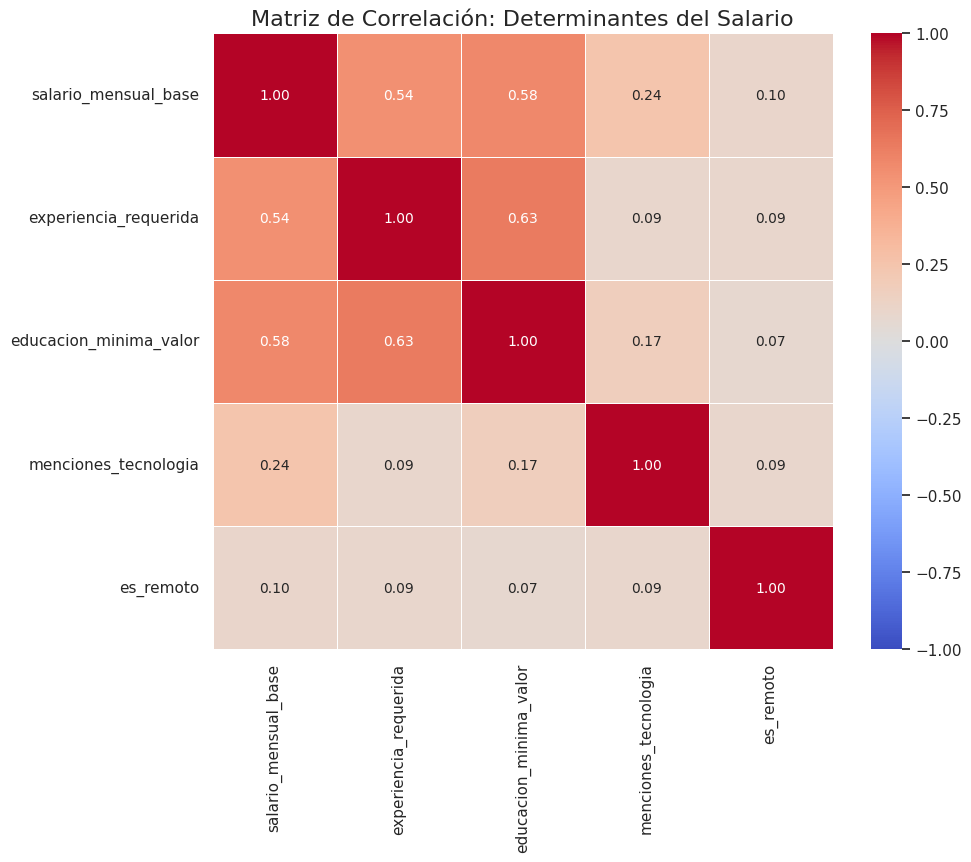

In [ ]:
cols_corr = ['salario_mensual_base', 'experiencia_requerida', 'educacion_minima_valor',
             'menciones_tecnologia', 'es_remoto']
corr_matrix = df_salarios[cols_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlación: Determinantes del Salario', fontsize=16)
plt.show()

## Análisis 2: Prima Remota

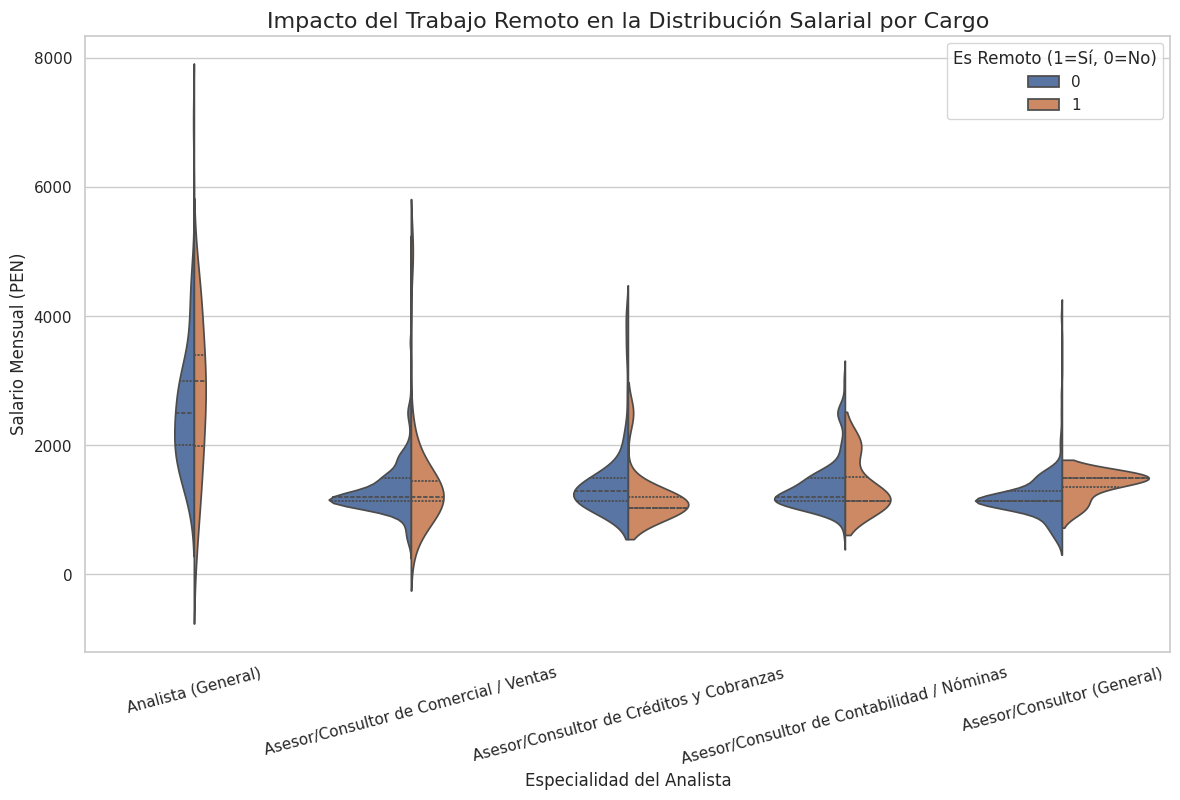

In [ ]:
top_cargos = df_salarios['cargo'].value_counts().head(5).index
df_top_cargos = df_salarios[df_salarios['cargo'].isin(top_cargos)]

plt.figure(figsize=(14, 8))
sns.violinplot(data=df_top_cargos, x='cargo', y='salario_mensual_base',
               hue='es_remoto', split=True, inner="quartile",
               palette={0: "#4c72b0", 1: "#dd8452"})
plt.title('Impacto del Trabajo Remoto en la Distribución Salarial por Cargo', fontsize=16)
plt.xlabel('Especialidad del Analista')
plt.ylabel('Salario Mensual (PEN)')
plt.legend(title='Es Remoto (1=Sí, 0=No)')
plt.xticks(rotation=15)
plt.show()


## Análisis 3: Transparencia

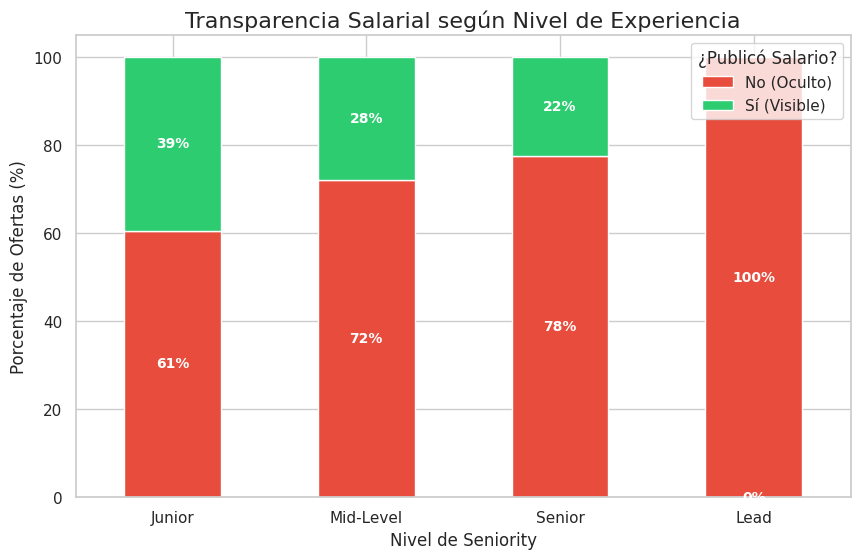

In [ ]:
ct_transparencia = pd.crosstab(df['seniority_nivel'], df['salario_publicado'], normalize='index') * 100

ax = ct_transparencia.plot(kind='bar', stacked=True, color=['#e74c3c', '#2ecc71'], figsize=(10, 6))

plt.title('Transparencia Salarial según Nivel de Experiencia', fontsize=16)
plt.xlabel('Nivel de Seniority')
plt.ylabel('Porcentaje de Ofertas (%)')
plt.legend(title='¿Publicó Salario?', labels=['No (Oculto)', 'Sí (Visible)'], loc='upper right')
plt.xticks(rotation=0)

for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%', label_type='center', color='white', weight='bold')
plt.show()

## Análisis 4: Jornada Precariedad

/tmp/ipython-input-3415982950.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(data=df_salarios, x='jornada', y='salario_mensual_base',
/tmp/ipython-input-3415982950.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_salarios, x='jornada', y='salario_mensual_base',


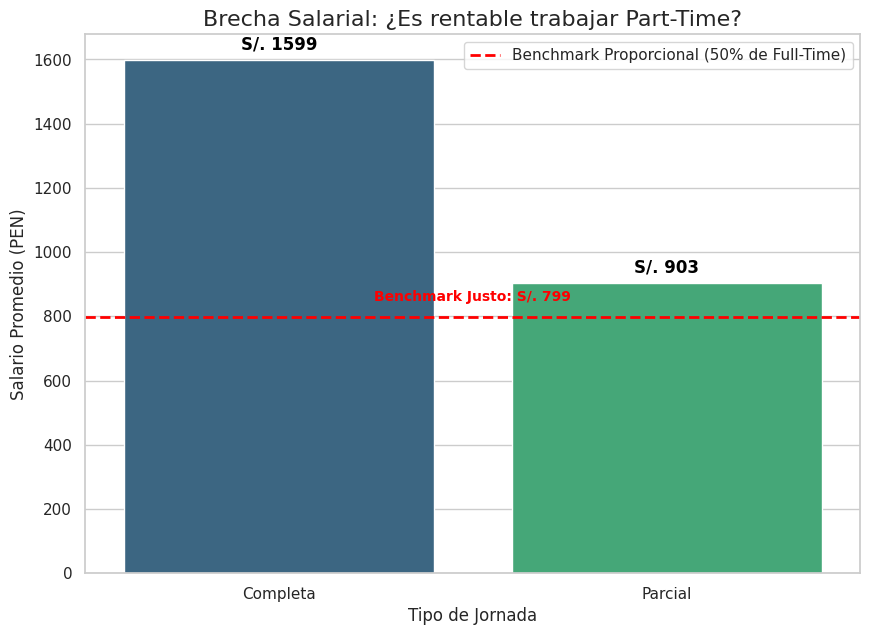

In [ ]:
promedio_full_time = df_salarios[df_salarios['jornada'] == 'Completa']['salario_mensual_base'].mean()
benchmark_justo = promedio_full_time * 0.5

plt.figure(figsize=(10, 7))
ax = sns.barplot(data=df_salarios, x='jornada', y='salario_mensual_base',
                 estimator=np.mean, ci=None, palette="viridis")
plt.axhline(y=benchmark_justo, color='red', linestyle='--', linewidth=2, label='Benchmark Proporcional (50% de Full-Time)')
plt.title('Brecha Salarial: ¿Es rentable trabajar Part-Time?', fontsize=16)
plt.xlabel('Tipo de Jornada')
plt.ylabel('Salario Promedio (PEN)')

for p in ax.patches:
    ax.annotate(f"S/. {p.get_height():.0f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, weight='bold', color='black', xytext=(0, 5),
                textcoords='offset points')

plt.text(x=0.5, y=benchmark_justo + 50, s=f"Benchmark Justo: S/. {benchmark_justo:.0f}",
         color='red', fontweight='bold', ha='center')

plt.legend()
plt.show()

## Análisis 5: Estabilidad de modalida de chamba

<Figure size 1000x600 with 0 Axes>

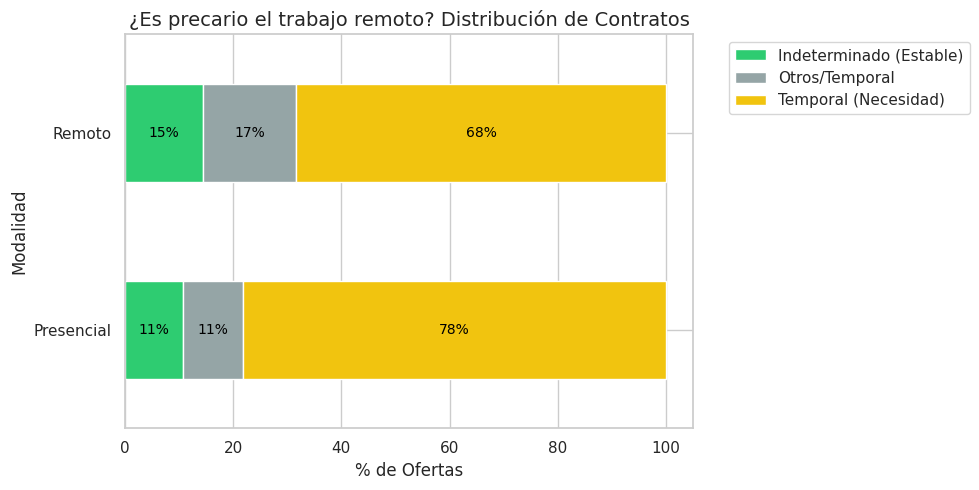

In [ ]:
def simplificar_contrato(texto):
    txt = str(texto).lower()
    if 'indeterminado' in txt: return 'Indeterminado (Estable)'
    if 'necesidades' in txt or 'incremento' in txt: return 'Temporal (Necesidad)'
    if 'locación' in txt or 'recibo' in txt: return 'Locación/Terceros'
    return 'Otros/Temporal'

df['contrato_simple'] = df['tipo_contrato'].apply(simplificar_contrato)
ct_contrato = pd.crosstab(df['es_remoto'], df['contrato_simple'], normalize='index') * 100

plt.figure(figsize=(10, 6))
ax = ct_contrato.plot(kind='barh', stacked=True, color=['#2ecc71', '#95a5a6', '#f1c40f', '#e74c3c'], figsize=(10, 5))
plt.title('¿Es precario el trabajo remoto? Distribución de Contratos', fontsize=14)
plt.ylabel('Modalidad')
plt.yticks([0, 1], ['Presencial', 'Remoto'])
plt.xlabel('% de Ofertas')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%', label_type='center', color='black')
plt.tight_layout()
plt.show()

### Insights: Para el reporte